# Make plots

I have copied the MSEED files into Dropbox

# 1. Setttings

In [2]:
from pathlib import Path
from obspy import read, UTCDateTime, Stream
 
launchtime = UTCDateTime('2026-04-01T22:35:12')
duration = 900
pretrigger = 1800
posttrigger = pretrigger
starttime=launchtime - pretrigger
endtime=launchtime + duration + posttrigger
starttrim = launchtime - 30
endtrim = launchtime + 270

MSEED_PATH = Path('~').expanduser() / 'Dropbox' / 'KSC_paper' / 'Artemis2' 

MAKE_STATION_PLOTS = False
CLIP_DATA = False


# 2. Read all the data from event files

In [ ]:
st = read(str(MSEED_PATH /  '2026*'))
st.merge()
print(st)

# get a list of stations, and then subset for each one, and plot
def get_stations(stream):
    return sorted(set(tr.stats.station for tr in stream))

def plot_station_traces(stream, starttime, endtime, equal_scale=False):
    for station in get_stations(stream):
        st_station = stream.select(station=station)
        st_station.plot(type='relative', starttime=starttime, endtime=endtime, show=True, equal_scale=equal_scale);

if MAKE_STATION_PLOTS:
    plot_station_traces(st, starttime=starttrim, endtime=endtrim)

# 3. Gem's must be instrument corrected first before any further processing, as otherwise they have giant steps

In [ ]:
import gemlog
st_gem = st.select(channel='HD[FI]')
st_gem.detrend(type='demean')
st_gem.filter("highpass", freq=0.5)
for tr in st_gem:
    if 'corrected' in tr.stats:
        continue
    tr = gemlog.deconvolve_gem_response(tr, gain='high') 
    tr.stats['corrected']=True
st_gem.plot(type='relative', starttime=starttrim, endtime=endtrim, show=True, equal_scale=False, outfile=MSEED_PATH / 'gem_traces_corrected.png');

# 4. Clip data to remove outliers (if set to True)

In [ ]:
import numpy as np

def clip_trace(trace, percentile=99.9):
    '''
    Clip the data in this Trace to +/- 2x the given percentile of the absolute value of the data.
    '''
    x = trace.data
    clip_level = np.nanpercentile(np.abs(x), percentile) * 2
    print(f"Clipping {trace.id} at {clip_level:.2f}")
    trace.data = np.clip(trace.data, -clip_level, clip_level)

def clip_stream(stream, percentile=99.9):
    for tr in stream:
        clip_trace(tr, percentile=percentile)

if CLIP_DATA:
    clip_stream(st, percentile=99.99)

# 5. Remove Trace objects with flat Trace data

These are typically unused sensor inputs

In [ ]:
import numpy as np

def is_flat_trace(trace_in, starttime=None, endtime=None, threshold=3.0):

    tr = trace_in.copy()
    tr.detrend(type='linear')
    tr.filter("highpass", freq=0.5)
    if starttime is not None and endtime is not None:
        tr.trim(starttime, endtime)

    data = tr.data.astype(float)

    if len(data) == 0:
        return True

    rms = np.sqrt(np.mean(data**2))
    peak = np.max(np.abs(data))

    if rms == 0:
        return True

    ratio = peak / rms

    return ratio < threshold

THRESHOLD_FLAT = 10.0
st_event = Stream() 
for station in get_stations(st):
    st_station = st.select(station=station)
    if MAKE_STATION_PLOTS:
        st_station.plot(type='relative', starttime=starttime, endtime=endtime, show=True, equal_scale=False);
    for tr in st_station:
        if is_flat_trace(tr, starttrim, endtrim, threshold=THRESHOLD_FLAT):
            print(f"Trace {tr.id} is flat (peak/RMS < {THRESHOLD_FLAT}), skipping.")
        else:
            st_event.append(tr)
print(st_event)


# 6. Correct Trilliums

In [ ]:
from flovopy.stationmetadata.build import NRL2inventory

st_trillium_corrected = st_event.select(network='1R', station='B*', channel="DH[ZNE12]")

for tr in st_trillium_corrected:
    if 'corrected' in tr.stats:
        continue
    print(tr.id, tr.stats.starttime, tr.stats.endtime)

    inv = NRL2inventory(
        nrl_path=None,   # use a local NRL copy
        net=tr.stats.network,
        sta=tr.stats.station,
        loc=tr.stats.location,
        chans=[tr.stats.channel],        # IMPORTANT: list, not string
        datalogger="Centaur",
        sensor="TCP",
        Vpp=40,
        fsamp=tr.stats.sampling_rate,
        lat=0.0,
        lon=0.0,
        elev=0.0,
        depth=0.0,
        sitename="",
        ondate=tr.stats.starttime,
        offdate=tr.stats.endtime,
        sensitivity=None,
        units=None,
    )

    fs = tr.stats.sampling_rate
    nyq = 0.5 * fs
    pre_filt = (0.01, 0.02, 0.94 * nyq, 0.98 * nyq)

    tr.remove_response(
        inventory=inv,
        output="VEL",
        pre_filt=pre_filt,
        zero_mean=True,
        taper=True,
    )
    tr.stats['corrected'] = True

st_trillium_corrected.plot(
    type="relative",
    starttime=starttrim,
    endtime=endtrim,
    show=True,
    equal_scale=False,
    outfile=MSEED_PATH / 'artemis2_trillium_stream_corrected.png'
);


# 7. Correct USF infrasound (Chaparral and infraBSU)

In [ ]:
st_infrabsu_corrected = st_event.select(network='1R', station='B*', channel="DD[012F]")  # or "HDF", "BDF", etc., depending on your naming

for tr in st_infrabsu_corrected:
    if 'corrected' in tr.stats:
        continue
    print(tr.id, tr.stats.starttime, tr.stats.endtime)

    if tr.stats.station == 'B20':
        print(f"Station {tr.stats.station} has channel {tr.stats.channel}, applying special handling for B20 DD0.")
        if tr.stats.channel == 'DDF':
            # chaparral sensor
            inv = NRL2inventory(
                nrl_path=None,   # strongly preferred over remote NRL
                net=tr.stats.network,
                sta=tr.stats.station,
                loc=tr.stats.location,
                chans=[tr.stats.channel],        # IMPORTANT: must be a list
                datalogger="Centaur",
                sensor="Chaparral",
                Vpp=40,
                fsamp=tr.stats.sampling_rate,
                lat=0.0,
                lon=0.0,
                elev=0.0,
                depth=0.0,
                sitename="",
                ondate=tr.stats.starttime,
                offdate=tr.stats.endtime,
                sensitivity=None,
                units="Pa",                      # only used by your fallback path
            )
        elif tr.stats.channel == 'DD0':
            # special case for B20 DD0, which is 40 Vpp since on same Sensor B as the Chaparral DDF
            print(f"Station {tr.stats.station} has channel {tr.stats.channel}, applying special handling for B20 DD0 with 40 Vpp.")
            inv = NRL2inventory(
                nrl_path=None,   # strongly preferred over remote NRL
                net=tr.stats.network,
                sta=tr.stats.station,
                loc=tr.stats.location,
                chans=[tr.stats.channel],        # IMPORTANT: must be a list
                datalogger="Centaur",
                sensor="infrabsu",
                Vpp=40,
                fsamp=tr.stats.sampling_rate,
                lat=0.0,
                lon=0.0,
                elev=0.0,
                depth=0.0,
                sitename="",
                ondate=tr.stats.starttime,
                offdate=tr.stats.endtime,
                sensitivity=None,
                units="Pa",                      # only used by your fallback path
            )
    else:
        print(f"Station {tr.stats.station} has channel {tr.stats.channel}, applying default handling for infrabsu with 1 Vpp.")
        
        inv = NRL2inventory(
            nrl_path=None,   # strongly preferred over remote NRL
            net=tr.stats.network,
            sta=tr.stats.station,
            loc=tr.stats.location,
            chans=[tr.stats.channel],        # IMPORTANT: must be a list
            datalogger="Centaur",
            sensor="infrabsu",
            Vpp=1,
            fsamp=tr.stats.sampling_rate,
            lat=0.0,
            lon=0.0,
            elev=0.0,
            depth=0.0,
            sitename="",
            ondate=tr.stats.starttime,
            offdate=tr.stats.endtime,
            sensitivity=None,
            units="Pa",                      # only used by your fallback path
        )

    before=np.nanmax(tr.data)


    fs = tr.stats.sampling_rate
    nyq = 0.5 * fs
    tr2 = tr.copy()
    tr2.detrend('linear')
    tr2.taper(0.05)
    tr2.filter('bandpass', freqmin=0.005, freqmax=0.94*nyq)
    tr2.filter('bandpass', freqmin=1.0, freqmax=2.0)
    tr2.trim(starttime=starttrim, endtime=endtrim)
    before=np.nanstd(tr2.data)

    # Example pre-filter; adjust to your actual infrasound band of interest
    pre_filt = (0.001, 0.005, 0.94 * nyq, 0.98 * nyq)

    tr.remove_response(
        inventory=inv,
        output="DEF",                    # safest for pressure/infrasound
        pre_filt=pre_filt,
        zero_mean=True,
        taper=True,
    )
    tr3 = tr.copy()
    tr3.filter('bandpass', freqmin=1.0, freqmax=2.0)
    tr3.trim(starttime=starttrim, endtime=endtrim)
    after=np.nanstd(tr3.data)
    correction_factor = before/after
    print(f'Correction factor applied is ~{correction_factor:.2e} but should be 736')
    additional_correction_factor = correction_factor / 736
    tr.data = tr.data * additional_correction_factor
    tr.stats['corrected'] = True


st_infrabsu_corrected.plot(type="relative", show=True, equal_scale=False, starttime=starttrim, endtime=endtrim, outfile=MSEED_PATH / 'artemis2_infrabsu_stream_corrected.png');

# 8. Put all the instrument corrected data together in a master Stream object

In [ ]:
master_stream = Stream()
for tr in st:
    if 'corrected' in tr.stats:
        master_stream.append(tr)
print(master_stream)
master_stream.write(MSEED_PATH / 'master_stream_corrected.mseed', format='MSEED')
master_stream.plot(type='relative', starttime=starttrim, endtime=endtrim, show=True, equal_scale=False, outfile=MSEED_PATH / 'master_stream_corrected.png');

# 9. Re-load the master corrected Stream, if necessary

In [3]:
from obspy import read, Stream
if not 'master_stream' in locals():
    master_stream = read(str(MSEED_PATH / 'master_stream_corrected.mseed'))

# 10. Summarize the peak values for each Trace

In [4]:
# Compute 1-s RSAM for each
from flovopy.processing.sam import RSAM
rsamobj = RSAM(stream=master_stream, sampling_interval=1, despike=True) 
rsamobj.write(MSEED_PATH)
#rsamobj.plot(metrics='max');
rsamobj.trim(starttime=starttrim, endtime=endtrim)

In [ ]:
rsamobj.select(channel='*[HL]*').plot(metrics='max', outfile=str(MSEED_PATH / 'artemis2_seismic_RSAM_1s_max.png'))
rsamobj.select(channel='*D*').plot(metrics='max', outfile=str(MSEED_PATH / 'artemis2_infrasound_RSAM_1s_max.png'))

In [5]:
import numpy as np
import pandas as pd
from obspy import UTCDateTime


def rms(x: np.ndarray) -> float:
    """
    Root-mean-square amplitude.
    """
    x = np.asarray(x, dtype=float)
    if x.size == 0:
        return np.nan
    return np.sqrt(np.mean(x**2))


def sliding_window_peak_index(abs_data: np.ndarray, nwin: int) -> int:
    """
    Return the start index of the contiguous window with the largest sum of
    absolute amplitudes.

    This identifies the 'highest-amplitude' window of fixed length.
    """
    if nwin <= 0:
        raise ValueError("nwin must be > 0")
    if abs_data.size == 0:
        return 0
    if nwin >= abs_data.size:
        return 0

    csum = np.cumsum(np.insert(abs_data, 0, 0.0))
    window_sums = csum[nwin:] - csum[:-nwin]
    return int(np.argmax(window_sums))


def summarize_trace_amplitudes(tr, window_sec: float = 1.0) -> dict:
    """
    Summarize a trace using full-trace extrema and statistics from the
    highest-amplitude sliding window.

    Parameters
    ----------
    tr : obspy.Trace
        Input trace. A copy should be passed if you do not want it modified.
    window_sec : float
        Length of analysis window in seconds.

    Returns
    -------
    dict
        Summary metrics for the trace.
    """
    tr = tr.copy()
    tr.detrend(type="demean")

    data = tr.data.astype(float)
    sr = float(tr.stats.sampling_rate)

    if data.size == 0 or sr <= 0:
        return {
            "SEED_id": tr.id,
            "trace_start": tr.stats.starttime.isoformat(),
            "trace_end": tr.stats.endtime.isoformat(),
            "sampling_rate": sr,
            "window_sec": window_sec,
            "pos_max": np.nan,
            "neg_max": np.nan,
            "abs_peak": np.nan,
            "win_start": None,
            "win_end": None,
            "median_abs": np.nan,
            "mean_abs": np.nan,
            "rms": np.nan,
            "std": np.nan,
        }

    pos_max = np.max(data)
    neg_max = np.min(data)
    abs_peak = np.max(np.abs(data))

    nwin = max(1, int(round(window_sec * sr)))
    abs_data = np.abs(data)
    i0 = sliding_window_peak_index(abs_data, nwin)
    i1 = min(i0 + nwin, data.size)

    win = data[i0:i1]
    win_abs = np.abs(win)

    win_start = tr.stats.starttime + (i0 / sr)
    win_end = tr.stats.starttime + ((i1 - 1) / sr)

    p_rms = rms(win)


    metrics = {
        "SEED_id": tr.id,
        "trace_start": tr.stats.starttime.isoformat(),
        "trace_end": tr.stats.endtime.isoformat(),
        "sampling_rate": sr,
        "window_sec": window_sec,

        "pos_max": float(pos_max),
        "neg_max": float(neg_max),
        "abs_peak": float(abs_peak),

        "win_start": win_start.isoformat(),
        "win_end": win_end.isoformat(),

        "median_abs": float(np.median(win_abs)),
        "mean_abs": float(np.mean(win_abs)),
        "rms": float(p_rms),
        "std": float(np.std(win, ddof=0)),
    }


    if tr.stats.channel[1]=='D':
        spl = rms_to_spl(p_rms)
        metrics["spl_db"]=float(spl)   # NEW
    
    return metrics

def rms_to_spl(p_rms, p_ref=20e-6):
    """
    Convert RMS pressure (Pa) to Sound Pressure Level (dB re 20 µPa).
    """
    if p_rms <= 0 or np.isnan(p_rms):
        return np.nan
    return 20.0 * np.log10(p_rms / p_ref)

# --------------------------------------------------------------------------
# Main analysis
# --------------------------------------------------------------------------
window_sec = 1.0  # adjustable

master_trim = master_stream.copy()
master_trim.trim(starttime=starttrim, endtime=endtrim)

master_trim_infrasound = master_trim.copy().select(channel="*D[FI012]")
master_trim_seismic = master_trim.copy().select(channel="*[HL][ZNE012]")

for index, this_stream in enumerate([master_trim_infrasound, master_trim_seismic]):
    if index == 0:
        trace_type = "Infrasound"
        digits = 1
    else:
        trace_type = "Seismic"
        digits = 6

    print(f"Processing {trace_type} traces:")

    rows = []
    for tr in this_stream:
        rows.append(summarize_trace_amplitudes(tr, window_sec=window_sec))

    df = pd.DataFrame(rows)

    # Sort by absolute peak amplitude, descending
    df = df.sort_values("abs_peak", ascending=False).reset_index(drop=True)

    # Save full-precision CSV
    out_csv = MSEED_PATH.parent / f"peak_{trace_type.lower()}_amplitudes.csv"
    df.to_csv(out_csv, index=False)

    # Display rounded copy
    df_display = df.copy()
    round_cols = ["pos_max", "neg_max", "abs_peak", "median_abs", "mean_abs", "rms", "std"]
    for col in round_cols:
        df_display[col] = df_display[col].round(digits)

    display(df_display)
    

Processing Infrasound traces:


,SEED_id,trace_start,trace_end,sampling_rate,window_sec,pos_max,neg_max,abs_peak,win_start,win_end,median_abs,mean_abs,rms,std,spl_db
0,1R.B14..HDI,2026-04-01T22:34:42,2026-04-01T22:39:42,100.0,1.0,569.4,-501.6,569.4,2026-04-01T22:35:27.960000,2026-04-01T22:35:28.950000,158.7,191.4,234.2,234.2,141.371071
1,1R.B14..HDF,2026-04-01T22:34:42,2026-04-01T22:39:42,100.0,1.0,537.5,-514.3,537.5,2026-04-01T22:35:23.930000,2026-04-01T22:35:24.920000,195.0,198.0,231.3,224.1,141.262304
2,1R.B01.00.DD0,2026-04-01T22:34:42,2026-04-01T22:39:42,500.0,1.0,507.0,-352.2,507.0,2026-04-01T22:35:33.714000,2026-04-01T22:35:34.712000,84.2,102.4,131.4,131.4,136.351626
3,1R.B01..HDI,2026-04-01T22:34:42,2026-04-01T22:39:42,100.0,1.0,417.8,-492.1,492.1,2026-04-01T22:35:33.850000,2026-04-01T22:35:34.840000,199.2,206.2,231.0,230.8,141.252262
4,1R.B01.00.DD1,2026-04-01T22:34:42,2026-04-01T22:39:42,500.0,1.0,475.3,-336.1,475.3,2026-04-01T22:35:33.802000,2026-04-01T22:35:34.800000,78.8,98.0,127.3,125.6,136.076654
5,1R.B01.00.DD2,2026-04-01T22:34:42,2026-04-01T22:39:42,500.0,1.0,443.4,-330.3,443.4,2026-04-01T22:35:33.764000,2026-04-01T22:35:34.762000,79.0,95.6,121.9,121.3,135.697076
6,1R.B05.00.DD0,2026-04-01T22:34:42,2026-04-01T22:39:42,500.0,1.0,359.5,-169.4,359.5,2026-04-01T22:35:20.210000,2026-04-01T22:35:21.208000,79.8,89.0,110.6,104.4,134.851114
7,1R.B12..HDF,2026-04-01T22:34:42,2026-04-01T22:39:42,100.0,1.0,272.7,-293.8,293.8,2026-04-01T22:35:38.460000,2026-04-01T22:35:39.450000,93.3,100.7,118.9,118.0,135.484952
8,1R.B03..HDI,2026-04-01T22:34:42,2026-04-01T22:39:42,100.0,1.0,210.7,-279.0,279.0,2026-04-01T22:35:34.450000,2026-04-01T22:35:35.440000,79.9,90.3,110.4,108.6,134.836403
9,1R.B07.10.HDF,2026-04-01T22:34:42,2026-04-01T22:39:42,100.0,1.0,166.1,-278.5,278.5,2026-04-01T22:35:47.230000,2026-04-01T22:35:48.220000,53.3,63.1,79.2,77.5,131.956732


Processing Seismic traces:


,SEED_id,trace_start,trace_end,sampling_rate,window_sec,pos_max,neg_max,abs_peak,win_start,win_end,median_abs,mean_abs,rms,std
0,1R.B01.00.DHZ,2026-04-01T22:34:42,2026-04-01T22:39:42,500.0,1.0,0.002616,-0.002910,0.002910,2026-04-01T22:35:37.322000,2026-04-01T22:35:38.320000,0.000691,0.000747,0.000918,0.000916
1,1R.B01.00.DH2,2026-04-01T22:34:42,2026-04-01T22:39:42,500.0,1.0,0.001848,-0.002195,0.002195,2026-04-01T22:35:33.294000,2026-04-01T22:35:34.292000,0.000589,0.000643,0.000774,0.000772
2,1R.B01.00.DH1,2026-04-01T22:34:42,2026-04-01T22:39:42,500.0,1.0,0.001795,-0.002044,0.002044,2026-04-01T22:35:30.622000,2026-04-01T22:35:31.620000,0.000516,0.000574,0.000678,0.000674
3,1R.B05.00.DHZ,2026-04-01T22:34:42,2026-04-01T22:39:42,500.0,1.0,0.001703,-0.000752,0.001703,2026-04-01T22:35:21.118000,2026-04-01T22:35:22.116000,0.000233,0.000245,0.000286,0.000286
4,1R.B29.00.DH2,2026-04-01T22:34:42,2026-04-01T22:39:42,500.0,1.0,0.001294,-0.001208,0.001294,2026-04-01T22:35:53.640000,2026-04-01T22:35:54.638000,0.000366,0.000400,0.000477,0.000477
5,1R.B29.00.DHZ,2026-04-01T22:34:42,2026-04-01T22:39:42,500.0,1.0,0.000979,-0.000847,0.000979,2026-04-01T22:35:53.032000,2026-04-01T22:35:54.030000,0.000270,0.000291,0.000352,0.000352
6,1R.B05.00.DH1,2026-04-01T22:34:42,2026-04-01T22:39:42,500.0,1.0,0.000918,-0.000863,0.000918,2026-04-01T22:35:21.118000,2026-04-01T22:35:22.116000,0.000283,0.000298,0.000347,0.000347
7,1R.B29.00.DH1,2026-04-01T22:34:42,2026-04-01T22:39:42,500.0,1.0,0.000666,-0.000657,0.000666,2026-04-01T22:35:53.128000,2026-04-01T22:35:54.126000,0.000184,0.000198,0.000240,0.000240
8,1R.B03.00.DH1,2026-04-01T22:34:42,2026-04-01T22:39:42,500.0,1.0,0.000073,-0.000044,0.000073,2026-04-01T22:35:32.198000,2026-04-01T22:35:33.196000,0.000006,0.000009,0.000013,0.000013
9,1R.B03.00.DHZ,2026-04-01T22:34:42,2026-04-01T22:39:42,500.0,1.0,0.000066,-0.000072,0.000072,2026-04-01T22:35:34.830000,2026-04-01T22:35:35.828000,0.000006,0.000010,0.000015,0.000015


# 11. Plot peak amplitudes on a map as sized circles

/Volumes/PulwtopHome/Developer/GitHub/KSCRocketSeismoHydrology/artemis2


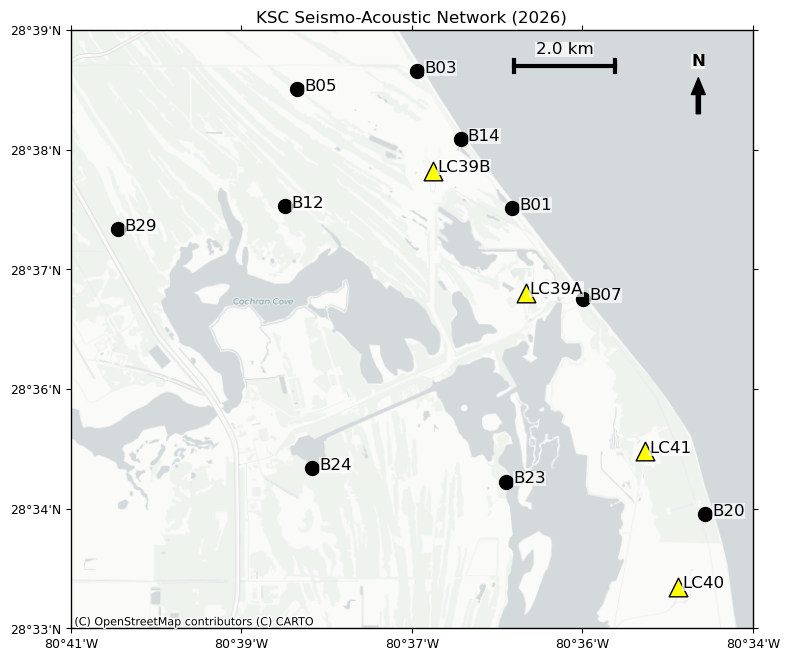

In [6]:
import sys
import os
from pathlib import Path
import contextily as cx

print(os.getcwd())
sys.path.append("../overview_paper")

from station_map import plot_station_map_tiles, save_figures

KSC_DIR = Path("~").expanduser() / "Dropbox" / "KSC_paper"
excelfile = KSC_DIR / "KSC_seismic_network_2016_2022.xls"

fig, ax, gdf = plot_station_map_tiles(
    excelfile,
    sheet_name="artemis2",
    launchpad_sheet="launchpads_2026",
    marker_size=100,
    marker_color="black",
    marker_edgecolor="black",
    label_size=12,
    label_color="black",
    label_dx_frac=0.010,
    label_dy_frac=0.005,
    basemap=cx.providers.CartoDB.Positron,
    group_clusters=True,
    cluster_frac_x=0.02,
    cluster_frac_y=0.02,
    grouped_name_mode="join",
    add_scalebar=True,
    scalebar_location=(0.65, 0.94),
    scalebar_color="black",
    scalebar_fontsize=12,
    scalebar_linewidth=3,
    add_north_arrow=True,
    north_arrow_color="black",
    north_arrow_linewidth=3,
    north_arrow_fontsize=12,
    add_latlon_ticks=True,
    launchpad_size=180,
    launchpad_color="yellow",
    launchpad_edgecolor="black",
    launchpad_marker="^",
    add_launchpad_labels=True,
    launchpad_label_size=12,
    launchpad_label_color="black",
    title="KSC Seismo-Acoustic Network (2026)",
)

save_figures(
    fig,
    outdir=KSC_DIR,
    outfilebase="ksc_map_2026_simple",
    formats=["png", "pdf"],
)

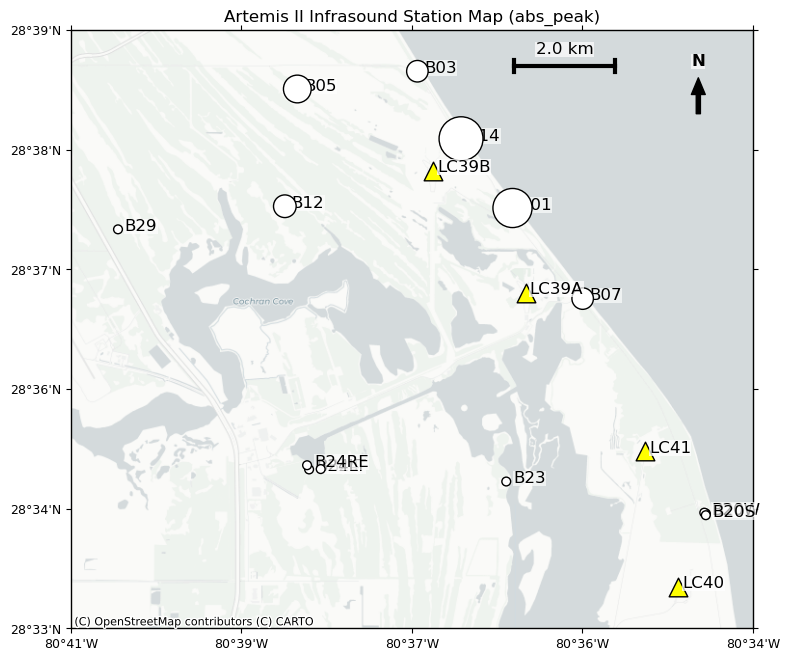

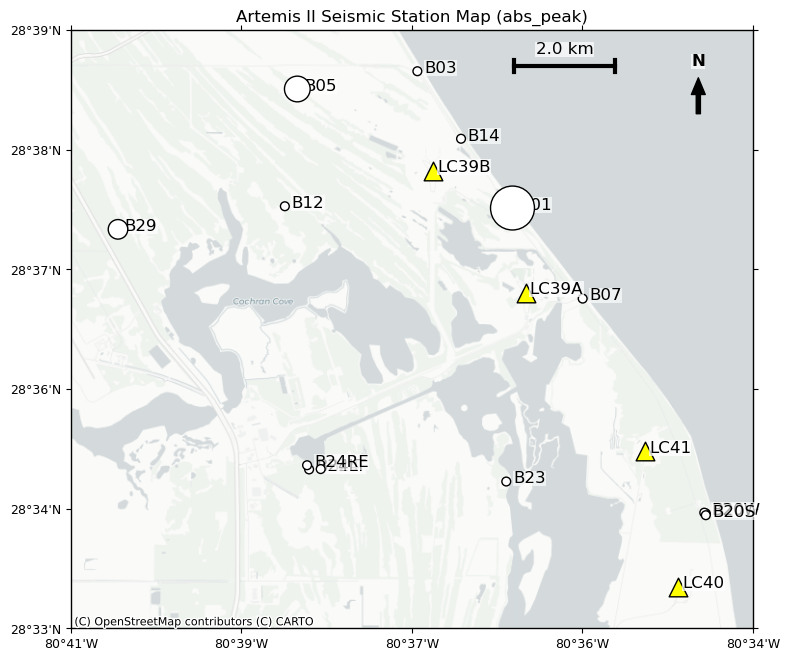

,station,abs_peak_station,marker_size_scaled
5,B14,569.405640,1000.000000
0,B01,507.033173,792.919721
2,B05,359.488373,398.589788
4,B12,293.793060,266.219300
1,B03,279.030151,240.136812
3,B07,278.492310,239.211958
9,B29,110.693428,40.000000
10,B24LT,108.144012,40.000000
11,B24RE,100.832840,40.000000
7,B23,83.425385,40.000000


,station,abs_peak_station,marker_size_scaled
0,B01,0.002910,1000.000000
2,B05,0.001703,342.597369
9,B29,0.001294,197.839710
1,B03,0.000073,40.000000
3,B07,NaN,40.000000
4,B12,NaN,40.000000
5,B14,NaN,40.000000
6,B20,NaN,40.000000
7,B23,NaN,40.000000
8,B24,NaN,40.000000


In [15]:
import numpy as np
import pandas as pd


def scale_symbol_sizes(
    values,
    *,
    mode="area",
    max_size=300.0,
    min_size=20.0,
    reference=None,
    clip_negative=True,
):
    """
    Scale marker sizes from amplitudes for use in matplotlib/geopandas.

    Parameters
    ----------
    values : array-like
        Amplitude values to convert into marker sizes.
    mode : {"area", "radius"}
        - "area": circle area is proportional to amplitude
        - "radius": circle radius is proportional to amplitude
    max_size : float
        Maximum marker size passed to matplotlib/geopandas for the
        largest amplitude. This is an area-like size parameter.
    min_size : float
        Minimum marker size for nonzero values.
    reference : float or None
        Reference amplitude corresponding to max_size.
        If None, uses the maximum finite value in `values`.
    clip_negative : bool
        If True, negative values are converted to absolute values.

    Returns
    -------
    sizes : np.ndarray
        Marker sizes suitable for matplotlib scatter/geopandas plot.
    """
    vals = np.asarray(values, dtype=float)

    if clip_negative:
        vals = np.abs(vals)

    vals[~np.isfinite(vals)] = np.nan

    if reference is None:
        if np.all(np.isnan(vals)):
            return np.full_like(vals, min_size, dtype=float)
        reference = np.nanmax(vals)

    if not np.isfinite(reference) or reference <= 0:
        return np.full_like(vals, min_size, dtype=float)

    ratio = vals / reference
    ratio = np.clip(ratio, 0.0, None)

    if mode == "area":
        # area proportional to amplitude
        sizes = max_size * ratio
    elif mode == "radius":
        # radius proportional to amplitude -> plotted size must scale as r^2
        sizes = max_size * ratio**2
    else:
        raise ValueError("mode must be 'area' or 'radius'")

    # keep zeros/very small values visible if desired
    sizes = np.where(np.isnan(sizes), min_size, sizes)
    sizes = np.where((ratio > 0) & (sizes < min_size), min_size, sizes)

    return sizes

# --- Single notebook cell: build sized station maps for infrasound and seismic ---

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import contextily as cx
import matplotlib.pyplot as plt

# --------------------------------------------------------------------------
# User settings
# --------------------------------------------------------------------------
KSC_DIR = Path("~").expanduser() / "Dropbox" / "KSC_paper"
excelfile = KSC_DIR / "KSC_seismic_network_2016_2022.xls"

# Where your amplitude CSVs were written earlier
amp_dir = MSEED_PATH.parent

# Choose which metric column to map
INFRA_COL = "abs_peak"   # alternatives: "rms", "abs_peak", "mean_abs"
SEIS_COL  = "abs_peak"      # alternatives: "abs_peak", "mean_abs", "std", 'RMS

# Symbol sizing options
SIZE_MODE = "radius"     # "area" or "radius"
MAX_MARKER_SIZE = 1000  # matplotlib/geopandas marker size for largest value
MIN_MARKER_SIZE = 40   # minimum visible symbol size

# --------------------------------------------------------------------------
# Helpers
# --------------------------------------------------------------------------
def seed_id_to_station(seed_id: str) -> str:
    """
    Convert SEED id NET.STA.LOC.CHA to station code STA.
    """
    parts = str(seed_id).split(".")
    return parts[1] if len(parts) > 1 else str(seed_id)


def scale_symbol_sizes(
    values,
    *,
    mode="area",
    max_size=300.0,
    min_size=20.0,
    reference=None,
    clip_negative=True,
):
    """
    Convert amplitudes into matplotlib/geopandas marker sizes.

    Parameters
    ----------
    values : array-like
        Amplitudes or metrics to scale.
    mode : {"area", "radius"}
        "area"   -> plotted circle area proportional to amplitude
        "radius" -> plotted circle radius proportional to amplitude
    max_size : float
        Marker size used for the largest amplitude.
    min_size : float
        Minimum marker size for nonzero finite values.
    reference : float or None
        Reference amplitude corresponding to max_size.
        If None, uses max(values).
    clip_negative : bool
        If True, uses abs(values).

    Returns
    -------
    np.ndarray
        Marker sizes suitable for matplotlib scatter / geopandas plot.
    """
    vals = np.asarray(values, dtype=float)

    if clip_negative:
        vals = np.abs(vals)

    vals[~np.isfinite(vals)] = np.nan

    if reference is None:
        if np.all(np.isnan(vals)):
            return np.full_like(vals, min_size, dtype=float)
        reference = np.nanmax(vals)

    if not np.isfinite(reference) or reference <= 0:
        return np.full_like(vals, min_size, dtype=float)

    ratio = vals / reference
    ratio = np.clip(ratio, 0.0, None)

    if mode == "area":
        sizes = max_size * ratio
    elif mode == "radius":
        sizes = max_size * ratio**2
    else:
        raise ValueError("mode must be 'area' or 'radius'")

    sizes = np.where(np.isnan(sizes), min_size, sizes)
    sizes = np.where((ratio > 0) & (sizes < min_size), min_size, sizes)
    return sizes


# --------------------------------------------------------------------------
# Load amplitude tables
# --------------------------------------------------------------------------
infra_csv = amp_dir / "peak_infrasound_amplitudes.csv"
seis_csv  = amp_dir / "peak_seismic_amplitudes.csv"

df_infra = pd.read_csv(infra_csv)
df_seis  = pd.read_csv(seis_csv)

df_infra["station"] = df_infra["SEED_id"].apply(seed_id_to_station)
df_seis["station"]  = df_seis["SEED_id"].apply(seed_id_to_station)

# --------------------------------------------------------------------------
# Reduce to one value per station
# (Change .max() to .mean() or another reducer if you prefer.)
# --------------------------------------------------------------------------
station_infra = (
    df_infra.groupby("station", as_index=False)[INFRA_COL]
    .max()
    .rename(columns={INFRA_COL: f"{INFRA_COL}_station"})
)

station_seis = (
    df_seis.groupby("station", as_index=False)[SEIS_COL]
    .max()
    .rename(columns={SEIS_COL: f"{SEIS_COL}_station"})
)

# --------------------------------------------------------------------------
# Load station coordinates from spreadsheet and merge metrics
# --------------------------------------------------------------------------
stations = pd.read_excel(excelfile, sheet_name="artemis2")

stations_infra = stations.merge(station_infra, on="station", how="left")
stations_seis  = stations.merge(station_seis,  on="station", how="left")

# --------------------------------------------------------------------------
# Compute marker sizes
# --------------------------------------------------------------------------
stations_infra["marker_size_scaled"] = scale_symbol_sizes(
    stations_infra[f"{INFRA_COL}_station"],
    mode=SIZE_MODE,
    max_size=MAX_MARKER_SIZE,
    min_size=MIN_MARKER_SIZE,
)

stations_seis["marker_size_scaled"] = scale_symbol_sizes(
    stations_seis[f"{SEIS_COL}_station"],
    mode=SIZE_MODE,
    max_size=MAX_MARKER_SIZE,
    min_size=MIN_MARKER_SIZE,
)

# --------------------------------------------------------------------------
# Plotting helper
# Uses your existing plot_station_map_tiles(), then overlays scaled circles.
# --------------------------------------------------------------------------
def make_scaled_station_map(
    station_df,
    *,
    title,
    excelfile=excelfile,
    station_sheet="artemis2",
    launchpad_sheet="launchpads_2026",
    marker_color="white",
    marker_edgecolor="black",
    label_size=12,
    label_color="black",
    label_dx_frac=0.010,
    label_dy_frac=0.005,
    basemap=cx.providers.CartoDB.Positron,
    launchpad_size=180,
    launchpad_color="yellow",
    launchpad_edgecolor="black",
    launchpad_marker="^",
):
    # Base map comes from the Excel workbook so launchpad_sheet can be read properly
    fig, ax, gdf_plot = plot_station_map_tiles(
        excelfile,
        sheet_name=station_sheet,
        launchpad_sheet=launchpad_sheet,
        marker_size=1,
        marker_color="white",
        marker_edgecolor="black",
        label_size=label_size,
        label_color=label_color,
        label_dx_frac=label_dx_frac,
        label_dy_frac=label_dy_frac,
        basemap=basemap,
        group_clusters=False,
        add_scalebar=True,
        scalebar_location=(0.65, 0.94),
        scalebar_color="black",
        scalebar_fontsize=12,
        scalebar_linewidth=3,
        add_north_arrow=True,
        north_arrow_color="black",
        north_arrow_linewidth=3,
        north_arrow_fontsize=12,
        add_latlon_ticks=True,
        launchpad_size=launchpad_size,
        launchpad_color=launchpad_color,
        launchpad_edgecolor=launchpad_edgecolor,
        launchpad_marker=launchpad_marker,
        add_launchpad_labels=True,
        launchpad_label_size=12,
        launchpad_label_color="black",
        title=title,
    )

    # Overlay scaled circles from the merged station dataframe
    gdf_scaled = gpd.GeoDataFrame(
        station_df.copy(),
        geometry=gpd.points_from_xy(station_df["lon"], station_df["lat"]),
        crs="EPSG:4326",
    ).to_crs(epsg=3857)

    ax.scatter(
        gdf_scaled.geometry.x,
        gdf_scaled.geometry.y,
        s=station_df["marker_size_scaled"].to_numpy(),
        c=marker_color,
        edgecolors=marker_edgecolor,
        zorder=7,
    )

    return fig, ax, gdf_scaled


# --------------------------------------------------------------------------
# Make the two maps
# --------------------------------------------------------------------------
fig_infra, ax_infra, gdf_infra = make_scaled_station_map(
    stations_infra,
    title=f"Artemis II Infrasound Station Map ({INFRA_COL})",
)

fig_seis, ax_seis, gdf_seis = make_scaled_station_map(
    stations_seis,
    title=f"Artemis II Seismic Station Map ({SEIS_COL})",
)

# --------------------------------------------------------------------------
# Save
# --------------------------------------------------------------------------
fig_infra.savefig(KSC_DIR / f"artemis2_infrasound_map_{INFRA_COL}.png", dpi=300, bbox_inches="tight")
fig_infra.savefig(KSC_DIR / f"artemis2_infrasound_map_{INFRA_COL}.pdf", dpi=300, bbox_inches="tight")

fig_seis.savefig(KSC_DIR / f"artemis2_seismic_map_{SEIS_COL}.png", dpi=300, bbox_inches="tight")
fig_seis.savefig(KSC_DIR / f"artemis2_seismic_map_{SEIS_COL}.pdf", dpi=300, bbox_inches="tight")

plt.show()

# Optional: inspect the merged tables
display(stations_infra[["station", INFRA_COL + "_station", "marker_size_scaled"]].sort_values(INFRA_COL + "_station", ascending=False))
display(stations_seis[["station", SEIS_COL + "_station", "marker_size_scaled"]].sort_values(SEIS_COL + "_station", ascending=False))

LC39B: lat=28.627220, lon=-80.620830


,station,lat,lon,distance_km,rms_station
5,B14,28.632222,-80.615833,0.739735,234.198190
0,B01,28.621389,-80.606667,1.526912,231.016563
1,B03,28.642778,-80.623611,1.751109,110.369768
4,B12,28.621667,-80.647222,2.648979,118.926219
2,B05,28.640000,-80.645000,2.753876,110.556863
3,B07,28.607222,-80.594167,3.423210,79.225792
8,B24,28.580556,-80.640833,5.544148,25.706090
7,B23,28.578611,-80.607778,5.553226,30.503160
11,B24RE,28.581160,-80.643260,5.570092,25.736263
9,B29,28.618056,-80.676944,5.571110,35.630994


,station,lat,lon,distance_km,rms_station
5,B14,28.632222,-80.615833,0.739735,NaN
0,B01,28.621389,-80.606667,1.526912,0.000918
1,B03,28.642778,-80.623611,1.751109,0.000015
4,B12,28.621667,-80.647222,2.648979,NaN
2,B05,28.640000,-80.645000,2.753876,0.000347
3,B07,28.607222,-80.594167,3.423210,NaN
8,B24,28.580556,-80.640833,5.544148,NaN
7,B23,28.578611,-80.607778,5.553226,NaN
11,B24RE,28.581160,-80.643260,5.570092,NaN
9,B29,28.618056,-80.676944,5.571110,0.000477


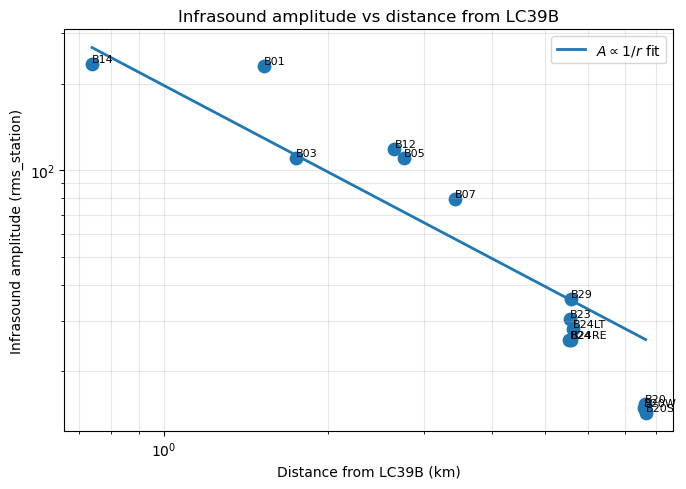

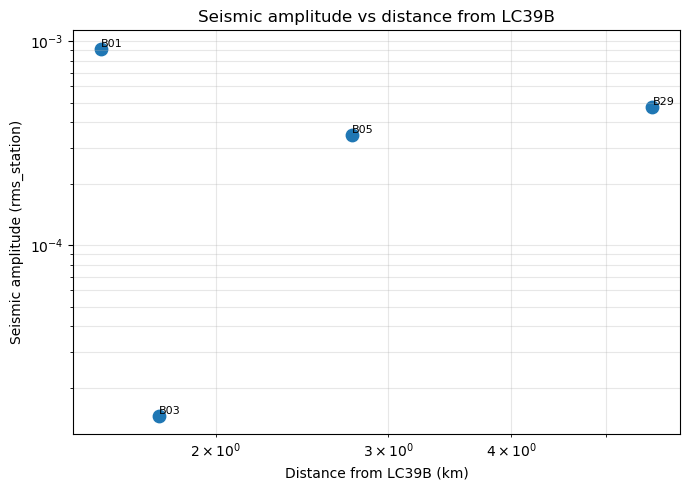

In [16]:
# --- Amplitude vs distance from LC39B ---

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------------------------------
# User settings
# --------------------------------------------------------------------------
KSC_DIR = Path("~").expanduser() / "Dropbox" / "KSC_paper"
excelfile = KSC_DIR / "KSC_seismic_network_2016_2022.xls"

station_sheet = "artemis2"
launchpad_sheet = "launchpads_2026"
launchpad_name = "LC39B"   # must match the 'pad' column in the launchpad sheet

# Which metric columns to plot
INFRA_COL = "rms_station"      # try: "rms_station", "abs_peak_station", "spl_db_station"
SEIS_COL  = "rms_station"      # try: "rms_station", "abs_peak_station"

# --------------------------------------------------------------------------
# Helpers
# --------------------------------------------------------------------------
def haversine_km(lon1, lat1, lon2, lat2):
    """
    Great-circle distance in km.
    """
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371.0 * c  # Earth radius in km


def seed_id_to_station(seed_id: str) -> str:
    parts = str(seed_id).split(".")
    return parts[1] if len(parts) > 1 else str(seed_id)


def fit_k_over_r(distance_km, amplitude):
    """
    Fit A = k/r in least-squares sense with k = mean(A*r) weighted by available data.
    """
    r = np.asarray(distance_km, dtype=float)
    a = np.asarray(amplitude, dtype=float)
    mask = np.isfinite(r) & np.isfinite(a) & (r > 0) & (a > 0)
    if not np.any(mask):
        return np.nan
    r = r[mask]
    a = a[mask]
    # Least squares fit for a = k / r  -> k ~ average(a*r)
    return np.mean(a * r)


# --------------------------------------------------------------------------
# Load amplitude tables and reduce to one value per station
# --------------------------------------------------------------------------
amp_dir = MSEED_PATH.parent

df_infra = pd.read_csv(amp_dir / "peak_infrasound_amplitudes.csv")
df_seis  = pd.read_csv(amp_dir / "peak_seismic_amplitudes.csv")

df_infra["station"] = df_infra["SEED_id"].apply(seed_id_to_station)
df_seis["station"]  = df_seis["SEED_id"].apply(seed_id_to_station)

station_infra = (
    df_infra.groupby("station", as_index=False)[INFRA_COL.replace("_station", "")]
    .max()
    .rename(columns={INFRA_COL.replace("_station", ""): INFRA_COL})
)

station_seis = (
    df_seis.groupby("station", as_index=False)[SEIS_COL.replace("_station", "")]
    .max()
    .rename(columns={SEIS_COL.replace("_station", ""): SEIS_COL})
)

# --------------------------------------------------------------------------
# Load station coordinates and launchpad coordinates from Excel
# --------------------------------------------------------------------------
stations = pd.read_excel(excelfile, sheet_name=station_sheet)
pads = pd.read_excel(excelfile, sheet_name=launchpad_sheet)

# Standardize expected column names
stations = stations.rename(columns={"lat": "lat", "lon": "lon", "station": "station"}).copy()
pads = pads.rename(columns={"pad": "pad", "lat": "lat", "lon": "lon"}).copy()

# Find LC39B
pad_row = pads.loc[pads["pad"].astype(str).str.upper() == launchpad_name.upper()]
if pad_row.empty:
    raise ValueError(f"Launchpad '{launchpad_name}' not found in sheet '{launchpad_sheet}'")

pad_lat = float(pad_row.iloc[0]["lat"])
pad_lon = float(pad_row.iloc[0]["lon"])

print(f"{launchpad_name}: lat={pad_lat:.6f}, lon={pad_lon:.6f}")

# Compute distances from LC39B
stations = stations.copy()
stations["distance_km"] = haversine_km(
    stations["lon"].astype(float).to_numpy(),
    stations["lat"].astype(float).to_numpy(),
    pad_lon,
    pad_lat,
)

# Merge with amplitudes
infra_dist = stations.merge(station_infra, on="station", how="left")
seis_dist  = stations.merge(station_seis,  on="station", how="left")

display(infra_dist[["station", "lat", "lon", "distance_km", INFRA_COL]].sort_values("distance_km"))
display(seis_dist[["station", "lat", "lon", "distance_km", SEIS_COL]].sort_values("distance_km"))

# --------------------------------------------------------------------------
# Plot 1: Infrasound amplitude vs distance with A ~ k/r reference line
# --------------------------------------------------------------------------
plot_infra = infra_dist.dropna(subset=[INFRA_COL, "distance_km"]).copy()
plot_infra = plot_infra[(plot_infra["distance_km"] > 0) & (plot_infra[INFRA_COL] > 0)].copy()

k_infra = fit_k_over_r(plot_infra["distance_km"], plot_infra[INFRA_COL])

r_fit = np.linspace(plot_infra["distance_km"].min(), plot_infra["distance_km"].max(), 200)
a_fit = k_infra / r_fit

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(plot_infra["distance_km"], plot_infra[INFRA_COL], s=80)

for _, row in plot_infra.iterrows():
    ax.text(row["distance_km"], row[INFRA_COL], str(row["station"]), fontsize=8, ha="left", va="bottom")

ax.plot(r_fit, a_fit, linewidth=2, label=r"$A \propto 1/r$ fit")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(f"Distance from {launchpad_name} (km)")
ax.set_ylabel(f"Infrasound amplitude ({INFRA_COL})")
ax.set_title(f"Infrasound amplitude vs distance from {launchpad_name}")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
fig.tight_layout()

fig.savefig(KSC_DIR / f"infrasound_{INFRA_COL}_vs_distance_{launchpad_name}.png", dpi=300, bbox_inches="tight")
fig.savefig(KSC_DIR / f"infrasound_{INFRA_COL}_vs_distance_{launchpad_name}.pdf", dpi=300, bbox_inches="tight")


# --------------------------------------------------------------------------
# Plot 2: Seismic amplitude vs distance
# --------------------------------------------------------------------------
plot_seis = seis_dist.dropna(subset=[SEIS_COL, "distance_km"]).copy()
plot_seis = plot_seis[(plot_seis["distance_km"] > 0) & (plot_seis[SEIS_COL] > 0)].copy()

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(plot_seis["distance_km"], plot_seis[SEIS_COL], s=80)

for _, row in plot_seis.iterrows():
    ax.text(row["distance_km"], row[SEIS_COL], str(row["station"]), fontsize=8, ha="left", va="bottom")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(f"Distance from {launchpad_name} (km)")
ax.set_ylabel(f"Seismic amplitude ({SEIS_COL})")
ax.set_title(f"Seismic amplitude vs distance from {launchpad_name}")
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()

fig.savefig(KSC_DIR / f"seismic_{SEIS_COL}_vs_distance_{launchpad_name}.png", dpi=300, bbox_inches="tight")
fig.savefig(KSC_DIR / f"seismic_{SEIS_COL}_vs_distance_{launchpad_name}.pdf", dpi=300, bbox_inches="tight")

plt.show()

LC39B: lat=28.627220, lon=-80.620830


,SEED_id,station,channel,distance_km,rms
1,1R.B14..HDF,B14,HDF,0.739735,231.283781
0,1R.B14..HDI,B14,HDI,0.739735,234.198190
3,1R.B01..HDI,B01,HDI,1.526912,231.016563
2,1R.B01.00.DD0,B01,DD0,1.526912,131.404818
4,1R.B01.00.DD1,B01,DD1,1.526912,127.310049
5,1R.B01.00.DD2,B01,DD2,1.526912,121.866349
8,1R.B03..HDI,B03,HDI,1.751109,110.369768
22,1R.B03.00.DD0,B03,DD0,1.751109,0.216446
7,1R.B12..HDF,B12,HDF,2.648979,118.926219
6,1R.B05.00.DD0,B05,DD0,2.753876,110.556863


,SEED_id,station,channel,distance_km,rms
2,1R.B01.00.DH1,B01,DH1,1.526912,0.000678
1,1R.B01.00.DH2,B01,DH2,1.526912,0.000774
0,1R.B01.00.DHZ,B01,DHZ,1.526912,0.000918
8,1R.B03.00.DH1,B03,DH1,1.751109,0.000013
11,1R.B03.00.DH2,B03,DH2,1.751109,0.000004
9,1R.B03.00.DHZ,B03,DHZ,1.751109,0.000015
6,1R.B05.00.DH1,B05,DH1,2.753876,0.000347
10,1R.B05.00.DH2,B05,DH2,2.753876,0.000007
3,1R.B05.00.DHZ,B05,DHZ,2.753876,0.000286
7,1R.B29.00.DH1,B29,DH1,5.571110,0.000240


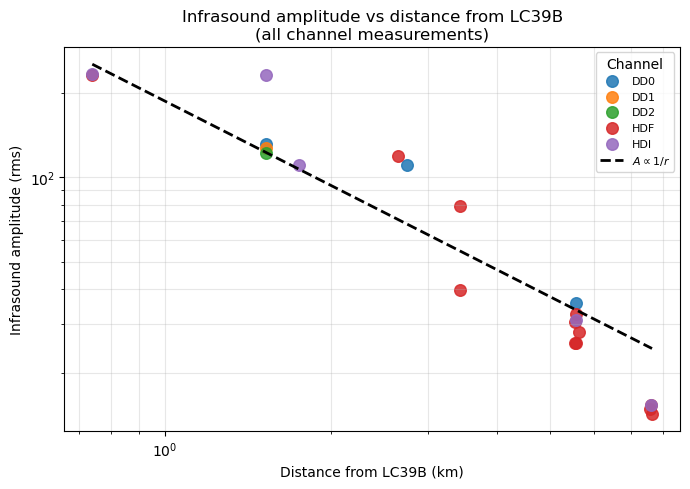

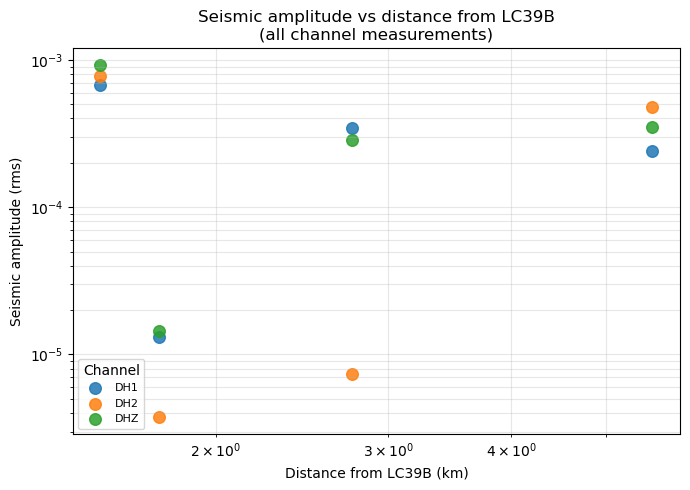

In [23]:
# --- Amplitude vs distance from LC39B, using every channel measurement ---

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------------------------------
# User settings
# --------------------------------------------------------------------------
KSC_DIR = Path("~").expanduser() / "Dropbox" / "KSC_paper"
excelfile = KSC_DIR / "KSC_seismic_network_2016_2022.xls"

station_sheet = "artemis2"
launchpad_sheet = "launchpads_2026"
launchpad_name = "LC39B"   # must match the 'pad' column in the launchpad sheet

# Choose which metric columns to plot
INFRA_COL = "rms"      # try: "rms", "abs_peak", "mean_abs", "spl_db"
SEIS_COL  = "rms"      # try: "rms", "abs_peak", "mean_abs", "std"

# Label points? Can get messy if True
LABEL_POINTS = False
LABEL_COLUMN = "SEED_id"   # "SEED_id", "station", or "channel"

# Add simple 1/r reference fit to infrasound
ADD_1_OVER_R_FIT = True

# --------------------------------------------------------------------------
# Helpers
# --------------------------------------------------------------------------
def haversine_km(lon1, lat1, lon2, lat2):
    """
    Great-circle distance in km.
    """
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371.0 * c


def seed_id_to_station(seed_id: str) -> str:
    parts = str(seed_id).split(".")
    return parts[1] if len(parts) > 1 else str(seed_id)


def seed_id_to_channel(seed_id: str) -> str:
    parts = str(seed_id).split(".")
    return parts[3] if len(parts) > 3 else ""


def fit_k_over_r(distance_km, amplitude):
    """
    Fit A = k/r in a simple least-squares sense using k ~ mean(A*r).
    """
    r = np.asarray(distance_km, dtype=float)
    a = np.asarray(amplitude, dtype=float)
    mask = np.isfinite(r) & np.isfinite(a) & (r > 0) & (a > 0)
    if not np.any(mask):
        return np.nan
    r = r[mask]
    a = a[mask]
    return np.mean(a * r)


# --------------------------------------------------------------------------
# Load channel-level amplitude tables
# --------------------------------------------------------------------------
amp_dir = MSEED_PATH.parent

df_infra = pd.read_csv(amp_dir / "peak_infrasound_amplitudes.csv")
df_seis  = pd.read_csv(amp_dir / "peak_seismic_amplitudes.csv")

# Extract station and channel from SEED id
for df_ in [df_infra, df_seis]:
    df_["station"] = df_["SEED_id"].apply(seed_id_to_station)
    df_["channel"] = df_["SEED_id"].apply(seed_id_to_channel)

# --------------------------------------------------------------------------
# Load station coordinates and launchpad coordinates from Excel
# --------------------------------------------------------------------------
stations = pd.read_excel(excelfile, sheet_name=station_sheet)
pads = pd.read_excel(excelfile, sheet_name=launchpad_sheet)

stations = stations.rename(columns={"station": "station", "lat": "lat", "lon": "lon"}).copy()
pads = pads.rename(columns={"pad": "pad", "lat": "lat", "lon": "lon"}).copy()

pad_row = pads.loc[pads["pad"].astype(str).str.upper() == launchpad_name.upper()]
if pad_row.empty:
    raise ValueError(f"Launchpad '{launchpad_name}' not found in sheet '{launchpad_sheet}'")

pad_lat = float(pad_row.iloc[0]["lat"])
pad_lon = float(pad_row.iloc[0]["lon"])

print(f"{launchpad_name}: lat={pad_lat:.6f}, lon={pad_lon:.6f}")

# Compute distance from launchpad for each station
stations = stations.copy()
stations["distance_km"] = haversine_km(
    stations["lon"].astype(float).to_numpy(),
    stations["lat"].astype(float).to_numpy(),
    pad_lon,
    pad_lat,
)

# Merge station coordinates onto every channel-level measurement
infra_dist = df_infra.merge(
    stations[["station", "lat", "lon", "distance_km"]],
    on="station",
    how="left",
)

seis_dist = df_seis.merge(
    stations[["station", "lat", "lon", "distance_km"]],
    on="station",
    how="left",
)

# Choose label column
for df_ in [infra_dist, seis_dist]:
    if LABEL_COLUMN not in df_.columns:
        df_["label"] = df_["SEED_id"]
    else:
        df_["label"] = df_[LABEL_COLUMN]

# Inspect merged tables
display(
    infra_dist[["SEED_id", "station", "channel", "distance_km", INFRA_COL]]
    .sort_values(["distance_km", "SEED_id"])
)

display(
    seis_dist[["SEED_id", "station", "channel", "distance_km", SEIS_COL]]
    .sort_values(["distance_km", "SEED_id"])
)

# --------------------------------------------------------------------------
# Plot 1: Infrasound amplitude vs distance, all channel measurements
# --------------------------------------------------------------------------
plot_infra = infra_dist.dropna(subset=[INFRA_COL, "distance_km"]).copy()
# Example: drop a specific SEED id
BAD_CHANNELS = [
    "1R.B03.00.DD0",   # replace with your actual SEED_id
]

plot_infra = plot_infra[~plot_infra["SEED_id"].isin(BAD_CHANNELS)].copy()
plot_infra = plot_infra[
    np.isfinite(plot_infra["distance_km"]) &
    np.isfinite(plot_infra[INFRA_COL]) &
    (plot_infra["distance_km"] > 0)
].copy()

# For log y-axis, keep positive values only
if INFRA_COL != "spl_db":
    plot_infra = plot_infra[plot_infra[INFRA_COL] > 0].copy()

fig, ax = plt.subplots(figsize=(7, 5))

# Color by channel so repeated measurements at one station are easier to spot
channels_infra = sorted(plot_infra["channel"].dropna().unique())
cmap = plt.get_cmap("tab10")
channel_colors = {ch: cmap(i % 10) for i, ch in enumerate(channels_infra)}

for ch in channels_infra:
    sub = plot_infra[plot_infra["channel"] == ch]
    ax.scatter(
        sub["distance_km"],
        sub[INFRA_COL],
        s=70,
        label=ch,
        color=channel_colors[ch],
        alpha=0.85,
    )

if LABEL_POINTS:
    for _, row in plot_infra.iterrows():
        ax.text(
            row["distance_km"],
            row[INFRA_COL],
            str(row["label"]),
            fontsize=7,
            ha="left",
            va="bottom",
        )

# Add 1/r reference fit only if plotting linear amplitude, not dB
if ADD_1_OVER_R_FIT and INFRA_COL != "spl_db":
    k_infra = fit_k_over_r(plot_infra["distance_km"], plot_infra[INFRA_COL])
    if np.isfinite(k_infra):
        r_fit = np.linspace(plot_infra["distance_km"].min(), plot_infra["distance_km"].max(), 200)
        a_fit = k_infra / r_fit
        ax.plot(r_fit, a_fit, linewidth=2, color="black", linestyle="--", label=r"$A \propto 1/r$")

ax.set_xscale("log")
if INFRA_COL != "spl_db":
    ax.set_yscale("log")

ax.set_xlabel(f"Distance from {launchpad_name} (km)")
ax.set_ylabel(f"Infrasound amplitude ({INFRA_COL})")
ax.set_title(f"Infrasound amplitude vs distance from {launchpad_name}\n(all channel measurements)")
ax.grid(True, which="both", alpha=0.3)
ax.legend(title="Channel", fontsize=8)
fig.tight_layout()

fig.savefig(KSC_DIR / f"infrasound_{INFRA_COL}_vs_distance_{launchpad_name}_all_channels_except_B03.DDO.png", dpi=300, bbox_inches="tight")
fig.savefig(KSC_DIR / f"infrasound_{INFRA_COL}_vs_distance_{launchpad_name}_all_channels_except_B03.DDO.pdf", dpi=300, bbox_inches="tight")

# --------------------------------------------------------------------------
# Plot 2: Seismic amplitude vs distance, all channel measurements
# --------------------------------------------------------------------------
plot_seis = seis_dist.dropna(subset=[SEIS_COL, "distance_km"]).copy()
plot_seis = plot_seis[
    np.isfinite(plot_seis["distance_km"]) &
    np.isfinite(plot_seis[SEIS_COL]) &
    (plot_seis["distance_km"] > 0) &
    (plot_seis[SEIS_COL] > 0)
].copy()

fig, ax = plt.subplots(figsize=(7, 5))

channels_seis = sorted(plot_seis["channel"].dropna().unique())
cmap = plt.get_cmap("tab10")
channel_colors = {ch: cmap(i % 10) for i, ch in enumerate(channels_seis)}

for ch in channels_seis:
    sub = plot_seis[plot_seis["channel"] == ch]
    ax.scatter(
        sub["distance_km"],
        sub[SEIS_COL],
        s=70,
        label=ch,
        color=channel_colors[ch],
        alpha=0.85,
    )

if LABEL_POINTS:
    for _, row in plot_seis.iterrows():
        ax.text(
            row["distance_km"],
            row[SEIS_COL],
            str(row["label"]),
            fontsize=7,
            ha="left",
            va="bottom",
        )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(f"Distance from {launchpad_name} (km)")
ax.set_ylabel(f"Seismic amplitude ({SEIS_COL})")
ax.set_title(f"Seismic amplitude vs distance from {launchpad_name}\n(all channel measurements)")
ax.grid(True, which="both", alpha=0.3)
ax.legend(title="Channel", fontsize=8)
fig.tight_layout()

fig.savefig(KSC_DIR / f"seismic_{SEIS_COL}_vs_distance_{launchpad_name}_all_channels.png", dpi=300, bbox_inches="tight")
fig.savefig(KSC_DIR / f"seismic_{SEIS_COL}_vs_distance_{launchpad_name}_all_channels.pdf", dpi=300, bbox_inches="tight")

plt.show()

In [25]:
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------
# STEP 1: prepare data (assumes you already have this)
# ---------------------------------------------------------------------
# plot_infra must contain:
#   distance_km
#   INFRA_COL (e.g. "spl_db" or "rms")
#   SEED_id

df = plot_infra.copy()

# Remove invalid values
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["distance_km", INFRA_COL]).copy()
df = df[df["distance_km"] > 0].copy()

# ---------------------------------------------------------------------
# STEP 2: fit A = k / r in log space
# ---------------------------------------------------------------------
x = np.log10(df["distance_km"].values)
y = np.log10(df[INFRA_COL].values)

# Linear fit: y = a + b*x  (should be slope ≈ -1)
b, a = np.polyfit(x, y, 1)

print(f"Fit: log10(A) = {a:.3f} + {b:.3f} log10(r)")
print(f"Expected slope ~ -1 → got {b:.3f}")

# ---------------------------------------------------------------------
# STEP 3: predicted amplitudes
# ---------------------------------------------------------------------
y_pred = a + b * x
A_pred = 10**y_pred

df["A_pred"] = A_pred

# ---------------------------------------------------------------------
# STEP 4: anomaly metrics
# ---------------------------------------------------------------------

# (1) Ratio (most intuitive physically)
df["anomaly_ratio"] = df[INFRA_COL] / df["A_pred"]

# (2) Log residual (best for plotting)
df["anomaly_log10"] = np.log10(df["anomaly_ratio"])

# (3) dB anomaly (great for infrasound)
df["anomaly_db"] = 20 * df["anomaly_log10"]

# ---------------------------------------------------------------------
# STEP 5: rank channels by anomaly
# ---------------------------------------------------------------------
df = df.sort_values("anomaly_ratio", ascending=False)

display(df[[
    "SEED_id",
    "distance_km",
    INFRA_COL,
    "A_pred",
    "anomaly_ratio",
    "anomaly_db"
]].round(3))

Fit: log10(A) = 2.362 + -1.218 log10(r)
Expected slope ~ -1 → got -1.218


,SEED_id,distance_km,rms,A_pred,anomaly_ratio,anomaly_db
7,1R.B12..HDF,2.649,118.926,70.296,1.692,4.567
3,1R.B01..HDI,1.527,231.017,137.537,1.680,4.504
6,1R.B05.00.DD0,2.754,110.557,67.048,1.649,4.344
9,1R.B07.10.HDF,3.423,79.226,51.437,1.540,3.752
11,1R.B29.00.DD0,5.571,35.631,28.418,1.254,1.965
13,1R.B29..HDF,5.571,32.484,28.418,1.143,1.161
15,1R.B29..HDI,5.571,31.108,28.418,1.095,0.786
16,1R.B23..HDF,5.553,30.503,28.530,1.069,0.581
12,1R.B24LT..HDF,5.624,28.173,28.093,1.003,0.025
2,1R.B01.00.DD0,1.527,131.405,137.537,0.955,-0.396


In [27]:
df_infra["win_start"] = pd.to_datetime(df_infra["win_start"], utc=True, errors="coerce")
launch_time_pd = pd.to_datetime(str(launchtime), utc=True)

df_infra["time_since_launch_s"] = (
    df_infra["win_start"] - launch_time_pd
).dt.total_seconds()

In [28]:
print(type(launchtime), launchtime)
print(df_infra["win_start"].iloc[0], type(df_infra["win_start"].iloc[0]))
print(launch_time_pd, type(launch_time_pd))

<class 'obspy.core.utcdatetime.UTCDateTime'> 2026-04-01T22:35:12.000000Z
2026-04-01 22:35:27.960000+00:00 <class 'pandas.Timestamp'>
2026-04-01 22:35:12+00:00 <class 'pandas.Timestamp'>


LC39B: lat=28.627220, lon=-80.620830


,SEED_id,station,channel,distance_km,win_start,time_since_launch_s
1,1R.B14..HDF,B14,HDF,0.739735,2026-04-01 22:35:23.930000+00:00,11.930
0,1R.B14..HDI,B14,HDI,0.739735,2026-04-01 22:35:27.960000+00:00,15.960
3,1R.B01..HDI,B01,HDI,1.526912,2026-04-01 22:35:33.850000+00:00,21.850
2,1R.B01.00.DD0,B01,DD0,1.526912,2026-04-01 22:35:33.714000+00:00,21.714
4,1R.B01.00.DD1,B01,DD1,1.526912,2026-04-01 22:35:33.802000+00:00,21.802
5,1R.B01.00.DD2,B01,DD2,1.526912,2026-04-01 22:35:33.764000+00:00,21.764
8,1R.B03..HDI,B03,HDI,1.751109,2026-04-01 22:35:34.450000+00:00,22.450
22,1R.B03.00.DD0,B03,DD0,1.751109,2026-04-01 22:35:17.204000+00:00,5.204
7,1R.B12..HDF,B12,HDF,2.648979,2026-04-01 22:35:38.460000+00:00,26.460
6,1R.B05.00.DD0,B05,DD0,2.753876,2026-04-01 22:35:20.210000+00:00,8.210


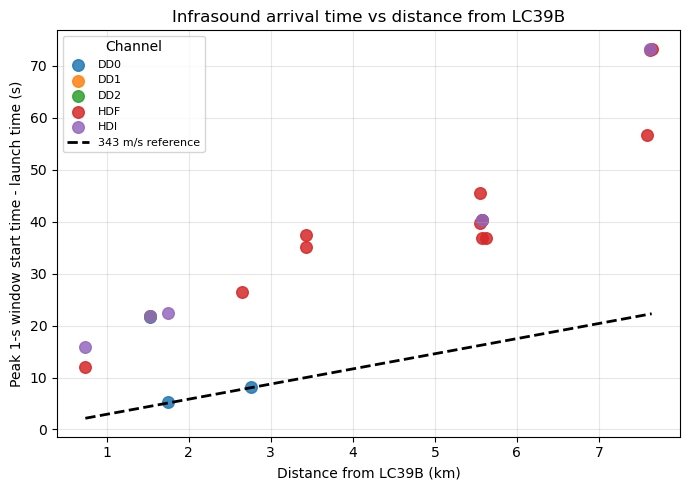

In [30]:
# --- Infrasound arrival time (win_start - launch_time) vs distance ---

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------------------------------
# User settings
# --------------------------------------------------------------------------
KSC_DIR = Path("~").expanduser() / "Dropbox" / "KSC_paper"
excelfile = KSC_DIR / "KSC_seismic_network_2016_2022.xls"

station_sheet = "artemis2"
launchpad_sheet = "launchpads_2026"
launchpad_name = "LC39B"

# Set the launch time here
# Example:
launch_time = pd.Timestamp("2026-04-01T05:47:00Z")   # <-- replace with actual launch time

# Expected sound speed for reference line
c_sound = 343.0  # m/s

# Label points?
LABEL_POINTS = False
LABEL_COLUMN = "SEED_id"   # or "station", "channel"

# --------------------------------------------------------------------------
# Helpers
# --------------------------------------------------------------------------
def haversine_km(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371.0 * c


def seed_id_to_station(seed_id: str) -> str:
    parts = str(seed_id).split(".")
    return parts[1] if len(parts) > 1 else str(seed_id)


def seed_id_to_channel(seed_id: str) -> str:
    parts = str(seed_id).split(".")
    return parts[3] if len(parts) > 3 else ""


# --------------------------------------------------------------------------
# Load channel-level metric tables
# --------------------------------------------------------------------------
amp_dir = MSEED_PATH.parent
infra_csv = amp_dir / "peak_infrasound_amplitudes.csv"
seis_csv  = amp_dir / "peak_seismic_amplitudes.csv"

df_infra = pd.read_csv(infra_csv)
df_seis  = pd.read_csv(seis_csv)

# Extract station and channel
df_infra["station"] = df_infra["SEED_id"].apply(seed_id_to_station)
df_infra["channel"] = df_infra["SEED_id"].apply(seed_id_to_channel)

df_infra["win_start"] = pd.to_datetime(df_infra["win_start"], utc=True, errors="coerce")
launch_time_pd = pd.to_datetime(str(launchtime), utc=True)

df_infra["time_since_launch_s"] = (
    df_infra["win_start"] - launch_time_pd
).dt.total_seconds()
'''
# Parse window start as datetime
df_infra["win_start"] = pd.to_datetime(df_infra["win_start"], utc=True, errors="coerce")

# Time since launch in seconds
df_infra["time_since_launch_s"] = (df_infra["win_start"] - launch_time).dt.total_seconds()
'''
# --------------------------------------------------------------------------
# Load station and launchpad coordinates from Excel
# --------------------------------------------------------------------------
stations = pd.read_excel(excelfile, sheet_name=station_sheet)
pads = pd.read_excel(excelfile, sheet_name=launchpad_sheet)

stations = stations.rename(columns={"station": "station", "lat": "lat", "lon": "lon"}).copy()
pads = pads.rename(columns={"pad": "pad", "lat": "lat", "lon": "lon"}).copy()

pad_row = pads.loc[pads["pad"].astype(str).str.upper() == launchpad_name.upper()]
if pad_row.empty:
    raise ValueError(f"Launchpad '{launchpad_name}' not found in sheet '{launchpad_sheet}'")

pad_lat = float(pad_row.iloc[0]["lat"])
pad_lon = float(pad_row.iloc[0]["lon"])

print(f"{launchpad_name}: lat={pad_lat:.6f}, lon={pad_lon:.6f}")

# Compute station distances to launchpad
stations = stations.copy()
stations["distance_km"] = haversine_km(
    stations["lon"].astype(float).to_numpy(),
    stations["lat"].astype(float).to_numpy(),
    pad_lon,
    pad_lat,
)

# Merge onto every infrasound channel record
infra_time = df_infra.merge(
    stations[["station", "lat", "lon", "distance_km"]],
    on="station",
    how="left",
)

if LABEL_COLUMN not in infra_time.columns:
    infra_time["label"] = infra_time["SEED_id"]
else:
    infra_time["label"] = infra_time[LABEL_COLUMN]

# Keep only valid rows
plot_df = infra_time.dropna(subset=["distance_km", "time_since_launch_s"]).copy()
plot_df = plot_df[np.isfinite(plot_df["distance_km"]) & np.isfinite(plot_df["time_since_launch_s"])].copy()
plot_df = plot_df[plot_df["distance_km"] > 0].copy()

display(
    plot_df[["SEED_id", "station", "channel", "distance_km", "win_start", "time_since_launch_s"]]
    .sort_values(["distance_km", "SEED_id"])
)

# --------------------------------------------------------------------------
# Plot: arrival time vs distance
# --------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))

channels = sorted(plot_df["channel"].dropna().unique())
cmap = plt.get_cmap("tab10")
channel_colors = {ch: cmap(i % 10) for i, ch in enumerate(channels)}

for ch in channels:
    sub = plot_df[plot_df["channel"] == ch]
    ax.scatter(
        sub["distance_km"],
        sub["time_since_launch_s"],
        s=70,
        label=ch,
        color=channel_colors[ch],
        alpha=0.85,
    )

if LABEL_POINTS:
    for _, row in plot_df.iterrows():
        ax.text(
            row["distance_km"],
            row["time_since_launch_s"],
            str(row["label"]),
            fontsize=7,
            ha="left",
            va="bottom",
        )

# Reference line for constant sound speed
r_km = np.linspace(plot_df["distance_km"].min(), plot_df["distance_km"].max(), 200)
t_ref = (r_km * 1000.0) / c_sound
ax.plot(r_km, t_ref, "k--", linewidth=2, label=f"{c_sound:.0f} m/s reference")

ax.set_xlabel(f"Distance from {launchpad_name} (km)")
ax.set_ylabel("Peak 1-s window start time - launch time (s)")
ax.set_title(f"Infrasound arrival time vs distance from {launchpad_name}")
ax.grid(True, alpha=0.3)
ax.legend(title="Channel", fontsize=8)
fig.tight_layout()

fig.savefig(KSC_DIR / f"infrasound_arrival_time_vs_distance_{launchpad_name}.png", dpi=300, bbox_inches="tight")
fig.savefig(KSC_DIR / f"infrasound_arrival_time_vs_distance_{launchpad_name}.pdf", dpi=300, bbox_inches="tight")

plt.show()


--- Linear fit ---
t = 5.31 + 0.007368 * r
Estimated propagation speed = 135.7 m/s

--- Quadratic fit ---
t = 17.78 + -0.001330 * r + 1.0327547301e-06 * r^2
Effective speed at mid-range ≈ 142.8 m/s


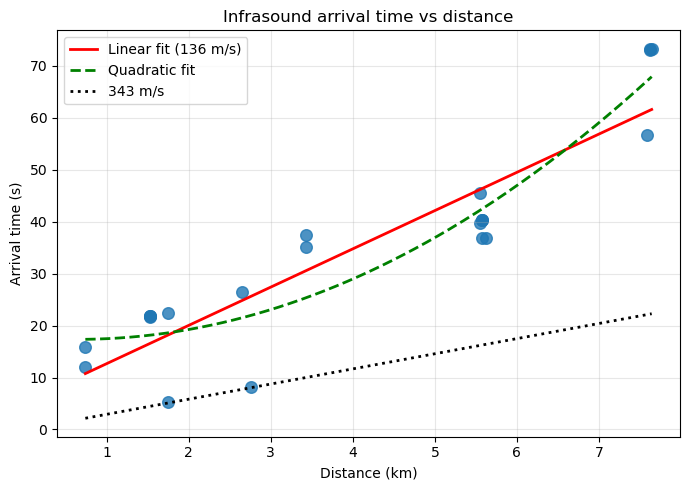

In [31]:
# --------------------------------------------------------------------------
# Fit arrival time vs distance
# --------------------------------------------------------------------------
import numpy as np

# Use clean data
fit_df = plot_df.copy()

# Independent variable: distance in meters
r = fit_df["distance_km"].values * 1000.0

# Dependent variable: time in seconds
t = fit_df["time_since_launch_s"].values

# Remove bad values
mask = np.isfinite(r) & np.isfinite(t) & (r > 0)
r = r[mask]
t = t[mask]

# --------------------------------------------------------------------------
# 1) LINEAR FIT: t = a + b r  → velocity = 1/b
# --------------------------------------------------------------------------
b, a = np.polyfit(r, t, 1)

velocity = 1.0 / b  # m/s

print("\n--- Linear fit ---")
print(f"t = {a:.2f} + {b:.6f} * r")
print(f"Estimated propagation speed = {velocity:.1f} m/s")

# --------------------------------------------------------------------------
# 2) QUADRATIC FIT: t = a + b r + c r^2
# --------------------------------------------------------------------------
c2, b2, a2 = np.polyfit(r, t, 2)

print("\n--- Quadratic fit ---")
print(f"t = {a2:.2f} + {b2:.6f} * r + {c2:.10e} * r^2")

# Effective "acceleration" interpretation
# If curvature exists, speed varies with distance:
# v(r) ≈ 1 / (b + 2 c r)

r_mid = np.mean(r)
v_mid = 1.0 / (b2 + 2 * c2 * r_mid)

print(f"Effective speed at mid-range ≈ {v_mid:.1f} m/s")

# --------------------------------------------------------------------------
# Plot everything
# --------------------------------------------------------------------------
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))

# Scatter data
ax.scatter(plot_df["distance_km"], plot_df["time_since_launch_s"], s=70, alpha=0.8)

# Smooth distance axis
r_plot_km = np.linspace(plot_df["distance_km"].min(), plot_df["distance_km"].max(), 200)
r_plot_m = r_plot_km * 1000.0

# Linear fit curve
t_lin = a + b * r_plot_m
ax.plot(r_plot_km, t_lin, "r-", linewidth=2, label=f"Linear fit ({velocity:.0f} m/s)")

# Quadratic fit curve
t_quad = a2 + b2 * r_plot_m + c2 * r_plot_m**2
ax.plot(r_plot_km, t_quad, "g--", linewidth=2, label="Quadratic fit")

# Reference sound speed
c_sound = 343.0
t_ref = (r_plot_m) / c_sound
ax.plot(r_plot_km, t_ref, "k:", linewidth=2, label="343 m/s")

# Labels
ax.set_xlabel("Distance (km)")
ax.set_ylabel("Arrival time (s)")
ax.set_title("Infrasound arrival time vs distance")

ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
plt.show()

,station,peak_time_s,peak_amplitude,peak_distance_m,peak_source_time_s,peak_phi_deg,peak_f_obs_hz,side,distance_km
0,W_00.5km,10.336002,0.000704,869.848597,7.8,33.682840,14.460066,West,0.869849
1,E_00.5km,11.129524,0.000736,833.326775,8.7,37.914750,14.101198,East,0.833327
2,W_01.0km,14.996402,0.000443,1610.865967,10.3,33.463852,13.459621,West,1.610866
3,E_01.0km,17.963206,0.000389,1770.979600,12.8,40.878460,12.241298,East,1.770980
4,W_01.5km,18.693197,0.000333,2295.766539,12.0,33.597730,12.920930,West,2.295767


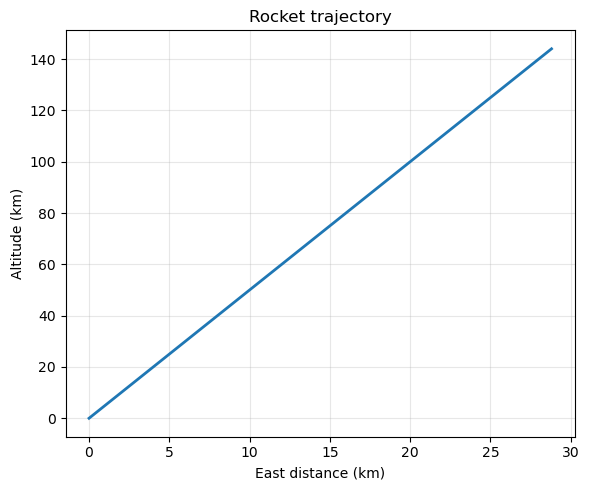

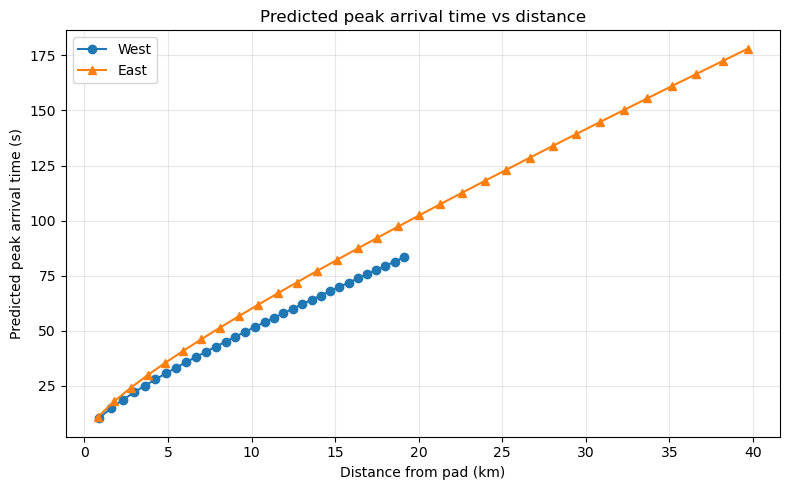

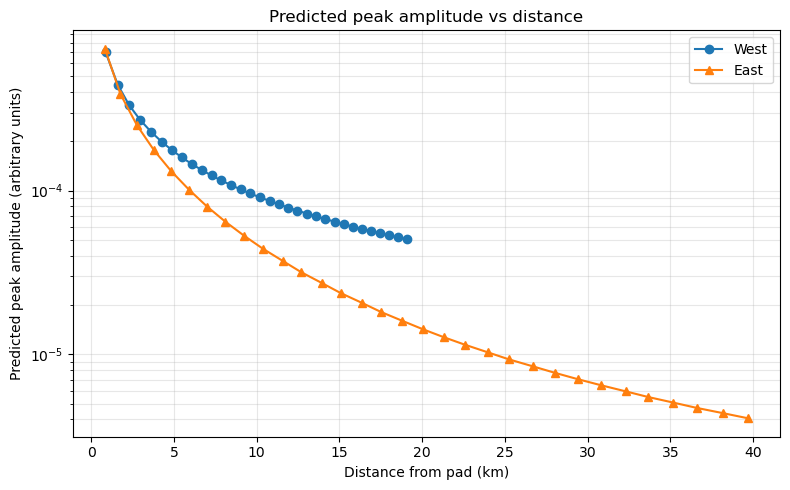

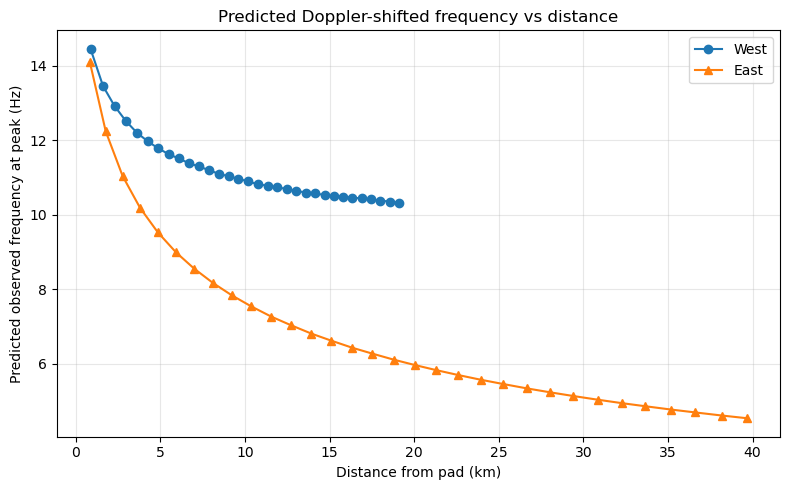

Saved synthetic_east_west_station_line_peak_metrics.csv


In [33]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Point this at wherever you unpacked the zip
sys.path.append('../rocket_infrasound_model')

from rocket_infrasound_model.model import RocketModel, Station
from rocket_infrasound_model.plotting import plot_trajectory, plot_network_peaks

# ------------------------------------------------------------------
# Build synthetic station line: west and east, every 0.5 km to 16 km
# ------------------------------------------------------------------
distances_km = np.arange(0.5, 16.0 + 0.001, 0.5)

stations = []
for d in distances_km:
    stations.append(Station(name=f"W_{d:04.1f}km", x_m=-1000.0 * d, z_m=0.0))
    stations.append(Station(name=f"E_{d:04.1f}km", x_m=+1000.0 * d, z_m=0.0))

# ------------------------------------------------------------------
# Define a simple rocket model
# ------------------------------------------------------------------
model = RocketModel(
    c_mps=343.0,      # sound speed
    q0=1.0,           # source strength scale
    phi0_deg=30.0,    # preferred radiation angle from exhaust axis
    sigma_deg=20.0,   # beam width
)

# ------------------------------------------------------------------
# Predict
# ------------------------------------------------------------------
result = model.predict_network(stations, t_max=120.0, dt=0.1)
peak_df = result.peak_metrics.copy()

# Add side and distance columns for easier plotting
peak_df["side"] = peak_df["station"].str[0].map({"W": "West", "E": "East"})
peak_df["distance_km"] = peak_df["peak_distance_m"] / 1000.0

display(peak_df.head())

# ------------------------------------------------------------------
# Plot 1: trajectory
# ------------------------------------------------------------------
fig, ax = plot_trajectory(model, t_max=120.0, dt=0.1)
plt.show()

# ------------------------------------------------------------------
# Plot 2: peak arrival time vs distance, east vs west
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

for side, marker in [("West", "o"), ("East", "^")]:
    sub = peak_df[peak_df["side"] == side]
    ax.plot(
        sub["distance_km"],
        sub["peak_time_s"],
        marker=marker,
        linestyle="-",
        label=side,
    )

ax.set_xlabel("Distance from pad (km)")
ax.set_ylabel("Predicted peak arrival time (s)")
ax.set_title("Predicted peak arrival time vs distance")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Plot 3: peak amplitude vs distance, east vs west
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

for side, marker in [("West", "o"), ("East", "^")]:
    sub = peak_df[peak_df["side"] == side]
    ax.plot(
        sub["distance_km"],
        sub["peak_amplitude"],
        marker=marker,
        linestyle="-",
        label=side,
    )

ax.set_xlabel("Distance from pad (km)")
ax.set_ylabel("Predicted peak amplitude (arbitrary units)")
ax.set_title("Predicted peak amplitude vs distance")
ax.set_yscale("log")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Plot 4: observed frequency at peak vs distance
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

for side, marker in [("West", "o"), ("East", "^")]:
    sub = peak_df[peak_df["side"] == side]
    ax.plot(
        sub["distance_km"],
        sub["peak_f_obs_hz"],
        marker=marker,
        linestyle="-",
        label=side,
    )

ax.set_xlabel("Distance from pad (km)")
ax.set_ylabel("Predicted observed frequency at peak (Hz)")
ax.set_title("Predicted Doppler-shifted frequency vs distance")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Optional: save synthetic peak table
# ------------------------------------------------------------------
out_csv = Path("./synthetic_east_west_station_line_peak_metrics.csv")
peak_df.to_csv(out_csv, index=False)
print(f"Saved {out_csv}")

# 12. Create audio files

In [ ]:
import numpy as np
from obspy import read
from scipy.io.wavfile import write as wavwrite
from scipy.signal import resample

def trace_to_audio(
    tr,
    speedup=100,
    output_wav="output.wav",
    audio_rate=44100,
    normalize=True,
    detrend=True,
    taper=True,
    bandpass=None,
):
    """
    Convert an ObsPy Trace to a WAV audio file by speeding it up.

    Parameters
    ----------
    tr : obspy.Trace
        Input seismic trace.
    speedup : float
        Factor by which to speed up playback.
    output_wav : str
        Output WAV filename.
    audio_rate : int
        Desired WAV sample rate in Hz.
    normalize : bool
        If True, scale data to int16 range.
    detrend : bool
        If True, remove mean and linear trend.
    taper : bool
        If True, apply a short taper.
    bandpass : tuple or None
        Optional (fmin, fmax) in Hz for pre-filtering the seismic data.
    """
    tr = tr.copy()

    if detrend:
        tr.detrend("linear")

    if taper:
        tr.taper(max_percentage=0.02)

    if bandpass is not None:
        fmin, fmax = bandpass
        tr.filter("bandpass", freqmin=fmin, freqmax=fmax, corners=4, zerophase=True)

    data = tr.data.astype(np.float64)

    # Remove NaNs/infs if present
    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)

    # Effective sampling rate after speeding up
    effective_rate = tr.stats.sampling_rate * speedup

    # Resample to desired audio rate if needed
    if abs(effective_rate - audio_rate) / audio_rate > 0.01:
        n_out = int(round(len(data) * audio_rate / effective_rate))
        if n_out <= 0:
            raise ValueError("Output sample count is invalid.")
        data = resample(data, n_out)

    if normalize:
        peak = np.max(np.abs(data))
        if peak > 0:
            data = data / peak
        data_int16 = np.int16(data * 32767)
    else:
        data_int16 = np.int16(np.clip(data, -32768, 32767))

    wavwrite(output_wav, audio_rate, data_int16)
    return output_wav


In [ ]:

for tr in master_stream.copy().trim(starttime=starttrim, endtime=endtrim):
    output_wav = MSEED_PATH.parent / f'{tr.id}_audio.wav'
    trace_to_audio(tr, speedup=60, output_wav=str(output_wav), audio_rate=44100, normalize=True, detrend=True, taper=True)#, bandpass=(0.1, 240))
    print(f'Created audio file: {output_wav}')

# 12. Near and far plots for 2 signals

In [ ]:
seismic_subset = Stream(traces=[master_stream.select(station='B01', channel='DHZ')[0],   master_stream.select(station='B29', channel='DHZ')[0]]).trim(starttime=starttrim, endtime=endtrim)
infrasound_subset = Stream(traces=[master_stream.select(station='B01', channel='DD0')[0],   master_stream.select(station='B29', channel='DD0')[0]]).trim(starttime=starttrim, endtime=endtrim)
seismic_subset.plot(equal_scale=True, outfile=MSEED_PATH / 'near_far_seismic_subset.pdf');
infrasound_subset.plot(equal_scale=True, outfile=MSEED_PATH / 'near_far_infrasound_subset.pdf');

In [ ]:

from flovopy.processing.spectrograms import icewebSpectrogram
iwobj = icewebSpectrogram(seismic_subset)
iwobj.precompute()
iwobj.plot(dbscale=True, equal_scale=True, fmax=250.0, clim=[1e-7, 1e-4], cmap='magma', add_colorbar=False, outfile=MSEED_PATH / 'near_far_seismic_spectrogram.png');

iwobji = icewebSpectrogram(infrasound_subset)
iwobji.precompute()
iwobji.plot(dbscale=True, equal_scale=True, fmax=250.0, clim=[2e-2, 2e1], cmap='magma', add_colorbar=False, outfile=MSEED_PATH / 'near_far_infrasound_spectrogram.png');
